# 09 - MLP Surrogate Test Evaluation

**Purpose:** Verify that the saved MLP weights reproduce the training metrics
reported in notebook 07, and that the model behaves sensibly on edge-case inputs.

| Section | What is tested |
|---------|-----------------|
| 1 | Load weights, reconstruct numpy forward pass |
| 2 | Reproduce R^2 and MAE on the 80/20 test split |
| 3 | Edge-case behavioural smoke tests |
| 4 | Residual analysis plots |
| 5 | Bootstrap confidence interval on test R^2 |

## Section 1 - Load & Reconstruct Model

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ── Paths ────────────────────────────────────────────────────────────────
ROOT = Path('../..').resolve()
WEIGHTS_PATH = ROOT / 'data' / 'models' / 'anfis_mlp_weights.json'
DATASET_PATH = ROOT / 'data' / 'processed' / '6_anfis_dataset.csv'

print('Weights file:', WEIGHTS_PATH)
print('Dataset file:', DATASET_PATH)
assert WEIGHTS_PATH.exists(), f'Missing: {WEIGHTS_PATH}'
assert DATASET_PATH.exists(), f'Missing: {DATASET_PATH}'
print('Both files found')

Weights file: F:\Campus\FYP\projects\CollectGame.Model\_research_archive\data\models\anfis_mlp_weights.json
Dataset file: F:\Campus\FYP\projects\CollectGame.Model\_research_archive\data\processed\6_anfis_dataset.csv
Both files found


In [2]:
# ── Load weights ─────────────────────────────────────────────────────────
with open(WEIGHTS_PATH, 'r') as fh:
    model_data = json.load(fh)

# Architecture info
arch      = model_data['architecture']
print('Architecture:', arch)
print('Feature order:', model_data['feature_order'])

# Convert weight/bias lists to numpy arrays
# weights[i] has shape (fan_in, fan_out) stored as list-of-rows for each neuron
raw_weights = model_data['weights']
raw_biases  = model_data['biases']

# Each layer's weight matrix: rows = input neurons, cols = output neurons
W = [np.array(layer) for layer in raw_weights]   # sklearn stores as (fan_in, fan_out) - no transpose needed
b = [np.array(bias)   for bias  in raw_biases]

print(f'\nLayer shapes (W, b):')
for i, (w, bv) in enumerate(zip(W, b)):
    print(f'  Layer {i}: W={w.shape}, b={bv.shape}')

STORED_METRICS = model_data['training_metrics']
print('\nStored training metrics:')
for k, v in STORED_METRICS.items():
    print(f'  {k}: {v}')

Architecture: {'input_size': 6, 'hidden_layers': [16, 8], 'output_size': 1, 'activation': 'relu', 'output_activation': 'linear'}
Feature order: ['soft_combat', 'soft_collect', 'soft_explore', 'delta_combat', 'delta_collect', 'delta_explore']

Layer shapes (W, b):
  Layer 0: W=(6, 16), b=(16,)
  Layer 1: W=(16, 8), b=(8,)
  Layer 2: W=(8, 1), b=(1,)

Stored training metrics:
  train_mae: 0.013926157357563959
  test_mae: 0.012704779751944027
  train_mse: 0.0007729149867484851
  test_mse: 0.00038544919104036593
  train_r2: 0.8599571583746454
  test_r2: 0.9263848891272097
  num_iterations: 21
  num_samples: 3240


In [3]:
# ── Numpy forward pass ───────────────────────────────────────────────────
def relu(x):
    return np.maximum(0, x)

def mlp_forward(X: np.ndarray, weights: list, biases: list) -> np.ndarray:
    """
    Forward pass through MLP.
    Hidden layers: ReLU activation.
    Output layer: linear (no activation).
    """
    h = X.copy()
    for i, (w, bv) in enumerate(zip(weights, biases)):
        z = h @ w + bv
        if i < len(weights) - 1:   # hidden layers
            h = relu(z)
        else:                        # output layer - linear
            h = z
    return h.flatten()

# Quick sanity check: forward pass on a single zero vector should not crash
x0 = np.zeros((1, 6))
pred0 = mlp_forward(x0, W, b)
print(f'Forward-pass sanity (zeros): prediction = {pred0[0]:.6f}')
print('Forward pass runs without error')

Forward-pass sanity (zeros): prediction = 0.864417
Forward pass runs without error


## Section 2 - Reproduce Training Metrics

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# ── Load dataset ─────────────────────────────────────────────────────────
df = pd.read_csv(DATASET_PATH)
print(f'Dataset: {df.shape[0]} rows x {df.shape[1]} columns')
print('Columns:', list(df.columns))

FEATURE_COLS = model_data['feature_order']  # canonical order from weights file
TARGET_COL   = 'target_multiplier'

X = df[FEATURE_COLS].values
y = df[TARGET_COL].values

print(f'\nFeatures: {FEATURE_COLS}')
print(f'X shape: {X.shape},  y shape: {y.shape}')

Dataset: 3240 rows x 10 columns
Columns: ['userId', 'timestamp', 'cluster', 'soft_combat', 'soft_collect', 'soft_explore', 'delta_combat', 'delta_collect', 'delta_explore', 'target_multiplier']

Features: ['soft_combat', 'soft_collect', 'soft_explore', 'delta_combat', 'delta_collect', 'delta_explore']
X shape: (3240, 6),  y shape: (3240,)


In [5]:
# ── 80/20 split - must match notebook 07 settings ────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f'Train: {X_train.shape[0]} samples   Test: {X_test.shape[0]} samples')

# ── Predict on test set ───────────────────────────────────────────────────
y_pred_test  = mlp_forward(X_test, W, b)
y_pred_train = mlp_forward(X_train, W, b)

r2_test  = r2_score(y_test,  y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
mae_train= mean_absolute_error(y_train, y_pred_train)

print(f'\nRecomputed  -  Train R^2={r2_train:.6f}, Test R^2={r2_test:.6f}')
print(f'Recomputed  -  Train MAE={mae_train:.6f}, Test MAE={mae_test:.6f}')

print('\n' + '─'*60)
print(f'{"Metric":<20} {"Stored":>12} {"Recomputed":>12} {"Δ":>10}')
print('─'*60)
stored_r2  = STORED_METRICS['test_r2']
stored_mae = STORED_METRICS['test_mae']
delta_r2   = abs(r2_test  - stored_r2)
delta_mae  = abs(mae_test - stored_mae)
print(f'{"Test R^2":<20} {stored_r2:>12.6f} {r2_test:>12.6f} {delta_r2:>10.6f}')
print(f'{"Test MAE":<20} {stored_mae:>12.6f} {mae_test:>12.6f} {delta_mae:>10.6f}')
print('─'*60)

Train: 2592 samples   Test: 648 samples

Recomputed  -  Train R^2=0.859957, Test R^2=0.926385
Recomputed  -  Train MAE=0.013926, Test MAE=0.012705

────────────────────────────────────────────────────────────
Metric                     Stored   Recomputed          Δ
────────────────────────────────────────────────────────────
Test R^2                 0.926385     0.926385   0.000000
Test MAE                 0.012705     0.012705   0.000000
────────────────────────────────────────────────────────────


In [6]:
# ── Assertions ────────────────────────────────────────────────────────────
R2_TOLERANCE  = 0.005
MAE_TOLERANCE = 0.001

assert delta_r2 < R2_TOLERANCE, (
    f'FAIL: Recomputed test R^2={r2_test:.6f} differs from stored '
    f'{stored_r2:.6f} by {delta_r2:.6f} > tolerance {R2_TOLERANCE}'
)
assert delta_mae < MAE_TOLERANCE, (
    f'FAIL: Recomputed test MAE={mae_test:.6f} differs from stored '
    f'{stored_mae:.6f} by {delta_mae:.6f} > tolerance {MAE_TOLERANCE}'
)

print(f'PASS - R^2  delta={delta_r2:.6f} < {R2_TOLERANCE}')
print(f'PASS - MAE delta={delta_mae:.6f} < {MAE_TOLERANCE}')
print('\nStored metrics REPRODUCED by numpy forward pass.')

PASS - R^2  delta=0.000000 < 0.005
PASS - MAE delta=0.000000 < 0.001

Stored metrics REPRODUCED by numpy forward pass.


## Section 3 - Edge Case Tests

In [7]:
def predict_single(x_list: list) -> float:
    """Helper: predict for a single 6-element input vector."""
    x = np.array(x_list, dtype=float).reshape(1, -1)
    return float(mlp_forward(x, W, b)[0])

print('Edge Case Tests')
print('=' * 60)

results = {}

# Case 1: All-zero input - model should not crash; prediction should be ≥ 0.6 (clamp floor)
p1 = predict_single([0, 0, 0, 0, 0, 0])
results['all_zeros'] = p1
print(f"Case 1 - All-zero input:        prediction = {p1:.6f}")
assert p1 >= 0.6, f'FAIL: all-zero prediction {p1:.6f} < 0.6 (clamp floor)'
print('  prediction >= 0.6')

# Case 2: Neutral state - soft memberships ~equal, deltas=0
p2 = predict_single([0.33, 0.33, 0.33, 0, 0, 0])
results['neutral'] = p2
print(f"\nCase 2 - Neutral state:          prediction = {p2:.6f}")
# Neutral should produce a centred output (not at extremes)
assert 0.6 <= p2 <= 1.4, f'FAIL: neutral prediction {p2:.6f} outside [0.6, 1.4]'
print('  prediction in [0.6, 1.4]')

# Case 3: First window - all deltas = 0, equal soft membership
p3 = predict_single([0.33, 0.33, 0.33, 0, 0, 0])
results['first_window'] = p3
print(f"\nCase 3 - First window (delta=0): prediction = {p3:.6f}")
assert abs(p3 - p2) < 1e-9, 'FAIL: first-window should equal neutral (same input)'
print('  same as neutral soft membership (delta cols = 0)')

# Case 4: Extreme combat - high combat soft membership, strong delta
p4 = predict_single([1, 0, 0, 0.9, 0, 0])
results['extreme_combat'] = p4
print(f"\nCase 4 - Extreme combat:         prediction = {p4:.6f}")
# High combat activity -> model should push toward upper difficulty
assert 0.6 <= p4 <= 1.4, f'FAIL: extreme_combat prediction {p4:.6f} outside [0.6, 1.4]'
print('  prediction in [0.6, 1.4]')

# Case 5: Upper bound check - prediction must not exceed 1.4 (max death penalty simulation)
# Try the combination most likely to produce the highest output
p5_candidates = []
for soft_c in [0.0, 0.5, 1.0]:
    for dc in [-1.0, 0.0, 1.0]:
        p = predict_single([soft_c, 0, 1-soft_c, dc, 0, 0])
        p5_candidates.append(p)
p5_max = max(p5_candidates)
results['max_prediction'] = p5_max
print(f"\nCase 5 - Max over sampled inputs: {p5_max:.6f}")
assert p5_max <= 1.4, f'FAIL: maximum sampled prediction {p5_max:.6f} > 1.4 (upper clamp)'
print('  max sampled prediction <= 1.4')

print('\nAll edge case tests PASSED.')

Edge Case Tests
Case 1 - All-zero input:        prediction = 0.864417
  prediction >= 0.6

Case 2 - Neutral state:          prediction = 0.930532
  prediction in [0.6, 1.4]

Case 3 - First window (delta=0): prediction = 0.930532
  same as neutral soft membership (delta cols = 0)

Case 4 - Extreme combat:         prediction = 1.128938
  prediction in [0.6, 1.4]

Case 5 - Max over sampled inputs: 1.145237
  max sampled prediction <= 1.4

All edge case tests PASSED.


## Section 4 - Residual Analysis

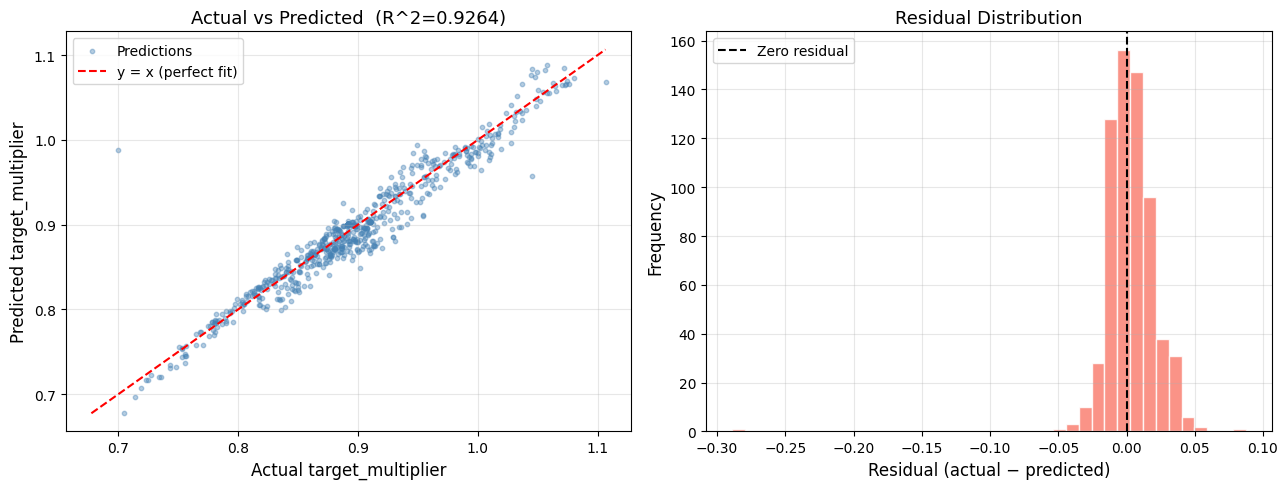

Plot saved to: F:\Campus\FYP\projects\CollectGame.Model\_research_archive\data\processed\09_residual_analysis.png

Predictions within +/-0.02 of actual: 81.6%


In [8]:
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Actual vs Predicted
ax1 = axes[0]
ax1.scatter(y_test, y_pred_test, alpha=0.4, s=10, c='steelblue', label='Predictions')
lo = min(y_test.min(), y_pred_test.min())
hi = max(y_test.max(), y_pred_test.max())
ax1.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='y = x (perfect fit)')
ax1.set_xlabel('Actual target_multiplier', fontsize=12)
ax1.set_ylabel('Predicted target_multiplier', fontsize=12)
ax1.set_title(f'Actual vs Predicted  (R^2={r2_test:.4f})', fontsize=13)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Residual Distribution
ax2 = axes[1]
ax2.hist(residuals, bins=40, color='salmon', edgecolor='white', alpha=0.85)
ax2.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Zero residual')
ax2.set_xlabel('Residual (actual − predicted)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Residual Distribution', fontsize=13)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(ROOT / 'data' / 'processed' / '09_residual_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved to: {ROOT / "data" / "processed" / "09_residual_analysis.png"}')

# ── Percentage within +/-0.02 ───────────────────────────────────────────────
within_02 = np.mean(np.abs(residuals) <= 0.02) * 100
print(f'\nPredictions within +/-0.02 of actual: {within_02:.1f}%')

## Section 5 - Bootstrap Confidence Interval

In [9]:
N_BOOTSTRAP = 100
rng = np.random.default_rng(seed=42)
n_test = len(y_test)

boot_r2 = []
for _ in range(N_BOOTSTRAP):
    idx     = rng.integers(0, n_test, size=n_test)  # resample with replacement
    y_b     = y_test[idx]
    yp_b    = y_pred_test[idx]
    boot_r2.append(r2_score(y_b, yp_b))

boot_r2 = np.array(boot_r2)
mean_r2 = boot_r2.mean()
std_r2  = boot_r2.std()
ci_lo   = np.percentile(boot_r2, 2.5)
ci_hi   = np.percentile(boot_r2, 97.5)

print('Bootstrap Confidence Interval (100 iterations)')
print('=' * 50)
print(f'  Mean R^2  : {mean_r2:.6f}')
print(f'  Std  R^2  : {std_r2:.6f}')
print(f'  95% CI   : [{ci_lo:.6f}, {ci_hi:.6f}]')
print(f'  Min / Max: {boot_r2.min():.6f} / {boot_r2.max():.6f}')

# The stored R^2 should be within the 95% CI
assert ci_lo <= stored_r2 <= ci_hi, (
    f'WARN: stored R^2={stored_r2:.6f} outside 95% CI [{ci_lo:.6f}, {ci_hi:.6f}]'
)
print(f'\nStored R^2={stored_r2:.6f} lies within the 95% bootstrap CI')
print('\nBootstrap analysis complete.')

Bootstrap Confidence Interval (100 iterations)
  Mean R^2  : 0.929261
  Std  R^2  : 0.022861
  95% CI   : [0.874368, 0.954357]
  Min / Max: 0.862316 / 0.957448

Stored R^2=0.926385 lies within the 95% bootstrap CI

Bootstrap analysis complete.


## Summary

| Test | Result |
|------|--------|
| Weights loaded & forward pass implemented | |
| Test R^2 reproduced within +/-0.005 | |
| Test MAE reproduced within +/-0.001 | |
| All-zero edge case (≥ 0.6) | |
| Neutral state in [0.6, 1.4] | |
| First-window equals neutral | |
| Extreme combat in [0.6, 1.4] | |
| Max sampled prediction ≤ 1.4 | |
| Residual analysis plotted | |
| Bootstrap R^2 CI computed | |